# Federated Learning in Natural Language Processing

Framework Reference : https://flower.ai/docs/framework/tutorial-series-what-is-federated-learning.html

### Dataset

IMDB dataset from Hugging Face

Task: การวิเคราะห์ความรู้สึก (Sentiment Analysis)

Detail: ชุดข้อมูลรีวิวภาพยนตร์จากเว็บไซต์ IMDB โดยมีการ label เป็น 2 class คือ positive และ negative

Link: https://huggingface.co/datasets/stanfordnlp/imdb

install

import library

In [1]:
# dataset
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
from typing import List
from collections import OrderedDict

# NLP
from transformers import BertModel, BertTokenizer, DataCollatorWithPadding

# Torch
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Flower framework
import flwr
from flwr.client import Client, ClientApp, NumPyClient
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
from flwr.common import ndarrays_to_parameters, NDArrays, Scalar, Context

DEVICE = torch.device("cuda")  # Try "cuda" to train on GPU
print(f"Training on {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")

2025-05-02 19:26:30.939999: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-02 19:26:31.038688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746188791.085340    5019 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746188791.097340    5019 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-02 19:26:31.189562: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Training on cuda
Flower 1.18.0 / PyTorch 2.7.0+cu118


### Load Dataset

In [2]:
#โหลด dataset
dataset = load_dataset("stanfordnlp/imdb")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


NOTE: Unsupervised dataset using for pre-training phase (Ignore)

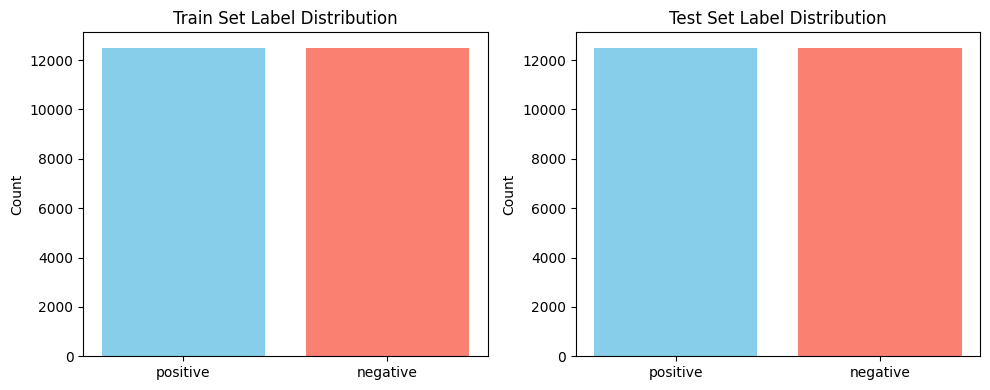

In [4]:
def count_labels(split):
    labels = dataset[split]['label']
    return {
        'positive': sum([1 for l in labels if l == 1]),
        'negative': sum([1 for l in labels if l == 0])
    }

# นับจำนวน label ใน train และ test
train_counts = count_labels('train')
test_counts = count_labels('test')

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# กราฟ train
axs[0].bar(train_counts.keys(), train_counts.values(), color=['skyblue', 'salmon'])
axs[0].set_title("Train Set Label Distribution")
axs[0].set_ylabel("Count")

# กราฟ test
axs[1].bar(test_counts.keys(), test_counts.values(), color=['skyblue', 'salmon'])
axs[1].set_title("Test Set Label Distribution")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Separate dataset for each client

In [3]:
NUM_PARTITIONS = 10
BATCH_SIZE = 32
MAX_LEN = 512

# Tokenization
tokenizer = BertTokenizer.from_pretrained("prajjwal1/bert-small")

# dataset["train"] → แบ่งเป็น train(80%) + val(20%)
train_texts_full = dataset["train"]["text"]
train_labels_full = dataset["train"]["label"]
train_texts, val_texts, train_labels, val_labels = train_test_split(train_texts_full, train_labels_full, test_size=0.2, random_state=42)

# Dataset for PyTorch
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "label": torch.tensor(self.labels[idx])
        }
    def __len__(self):
        return len(self.labels)

def partition_dataset(texts, labels, num_partitions):
    total = len(texts)
    indices = np.arange(total)
    np.random.shuffle(indices)
    size = total // num_partitions
    partitions = []
    for i in range(num_partitions):
        part_idx = indices[i * size: (i + 1) * size]
        part_texts = [texts[i] for i in part_idx]
        part_labels = [labels[i] for i in part_idx]
        partitions.append((part_texts, part_labels))
    return partitions

def load_datasets(partition_id: int, num_partitions: int = NUM_PARTITIONS):
    train_partitions = partition_dataset(train_texts, train_labels, num_partitions)
    val_partitions = partition_dataset(val_texts, val_labels, num_partitions)

    train_texts_part, train_labels_part = train_partitions[partition_id]
    val_texts_part, val_labels_part = val_partitions[partition_id]

    # Tokenize training set
    train_encodings = tokenizer(train_texts_part, truncation=True, padding=True, max_length=MAX_LEN)
    train_dataset = IMDBDataset(train_encodings, train_labels_part)

    # Tokenize validation set
    val_encodings = tokenizer(val_texts_part, truncation=True, padding=True, max_length=MAX_LEN)
    val_dataset = IMDBDataset(val_encodings, val_labels_part)

    # Tokenize test set
    test_encodings = tokenizer(dataset["test"]["text"], truncation=True, padding=True, max_length=MAX_LEN)
    test_dataset = IMDBDataset(test_encodings, dataset["test"]["label"])

    # Dataloaders
    trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    testloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    return trainloader, valloader, testloader

In [6]:
num_partitions = 10

# train และ val
train_partitions = partition_dataset(train_texts, train_labels, num_partitions)
val_partitions = partition_dataset(val_texts, val_labels, num_partitions)

# ปริ้นจำนวนตัวอย่างในแต่ละ client
for i in range(num_partitions):
    train_texts_part, _ = train_partitions[i]
    val_texts_part, _ = val_partitions[i]

    print(f"Client {i}:")
    print(f"  Train size: {len(train_texts_part)}")
    print(f"  Val size:   {len(val_texts_part)}")
    print("-" * 30)

Client 0:
  Train size: 2000
  Val size:   500
------------------------------
Client 1:
  Train size: 2000
  Val size:   500
------------------------------
Client 2:
  Train size: 2000
  Val size:   500
------------------------------
Client 3:
  Train size: 2000
  Val size:   500
------------------------------
Client 4:
  Train size: 2000
  Val size:   500
------------------------------
Client 5:
  Train size: 2000
  Val size:   500
------------------------------
Client 6:
  Train size: 2000
  Val size:   500
------------------------------
Client 7:
  Train size: 2000
  Val size:   500
------------------------------
Client 8:
  Train size: 2000
  Val size:   500
------------------------------
Client 9:
  Train size: 2000
  Val size:   500
------------------------------


## Step 1: Centralized Training with PyTorch

### Define the model

Model : BERT Small Model

Link : https://huggingface.co/prajjwal1/bert-small

In [4]:
class SentimentClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super(SentimentClassifier, self).__init__()
        self.bert = BertModel.from_pretrained("prajjwal1/bert-small")

        hidden_size = self.bert.config.hidden_size

        # Layer เพิ่มเติมสำหรับ classification
        self.drop = nn.Dropout(p=dropout)
        self.out = nn.Linear(hidden_size, 2)  # 2 classes: positive, negative

    def forward(self, input_ids, attention_mask):
        # BERT outputs: last_hidden_state, pooled_output
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # ใช้ pooled_output ซึ่งเป็น representation ของ [CLS] token
        pooled_output = outputs.pooler_output
        output = self.drop(pooled_output)
        return self.out(output)

In [5]:
def set_parameters(net, parameters: List[np.ndarray]):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)

def get_parameters(net) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in net.state_dict().items()]

training and test functions:

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(net, trainloader, epochs: int, verbose=False):
    """Train the BERT model on the training set."""
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=2e-5)
    net.to(DEVICE)
    net.train()

    for epoch in range(epochs):
        correct, total, epoch_loss = 0, 0, 0.0
        for batch in trainloader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            outputs = net(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            total += labels.size(0)
            correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
        epoch_loss /= len(trainloader)
        epoch_acc = correct / total
        # print(f"Epoch {epoch+1}: train loss {epoch_loss}, accuracy {epoch_acc}")

        return epoch_loss, epoch_acc

def test(net, testloader):
    """Evaluate the BERT model on the test set."""
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    net.to(DEVICE)
    net.eval()

    with torch.no_grad():
        for batch in testloader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            outputs = net(input_ids=input_ids, attention_mask=attention_mask)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    loss /= len(testloader)
    accuracy = correct / total
    return loss, accuracy

To train the model on the dataset of one of our organizations (partition_id=0). This simulates the reality of most machine learning projects today: each organization has their own data and trains models only on this internal data:

## Step 2: Federated Learning with Flower

### The Flower Client

* `get_parameters`: Return the current local model parameters
* `fit`: Receive model parameters from the server, train the model on the local data, and return the updated model parameters to the server
* `evaluate`: Receive model parameters from the server, evaluate the model on the local data, and return the evaluation result to the server

In [7]:
class FlowerClient(NumPyClient):
    def __init__(self, partition_id, net, trainloader, valloader):
        self.partition_id = partition_id
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        print(f"[Client {self.partition_id}] get_parameters")
        return get_parameters(self.net)

    def fit(self, parameters, config):
        print(f"[Client {self.partition_id}] fit, config: {config}")
        set_parameters(self.net, parameters)
        train_loss, train_acc = train(self.net, self.trainloader, epochs=3)
        return get_parameters(self.net), len(self.trainloader), {"train_loss": train_loss,"train_acc": train_acc,}

    def evaluate(self, parameters, config):
        print(f"[Client {self.partition_id}] evaluate, config: {config}")
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        print(f"[Client {self.partition_id}] evaluation result - loss: {loss:.4f}, accuracy: {accuracy:.4f}")
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}

def client_fn(context: Context) -> Client:
    net = SentimentClassifier().to(DEVICE)

    # Read the node_config to fetch data partition associated to this node
    partition_id = context.node_config["partition-id"]
    num_partitions = context.node_config["num-partitions"]

    trainloader, valloader, _ = load_datasets(partition_id, num_partitions)
    return FlowerClient(partition_id, net, trainloader, valloader).to_client()

# Create the ClientApp
client = ClientApp(client_fn=client_fn)

### The Flower Sever

Server-side parameter initialization

In [8]:
# Create an instance of the model and get the parameters
params = get_parameters(SentimentClassifier())

### Client Evaluation

In [9]:
from typing import List, Tuple, Dict
from flwr.common import NDArrays, Scalar

 Accuracy of Client

In [10]:
Metrics = Dict[str, float]

def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # Aggregate and return custom metric (weighted average)
    return {"accuracy": sum(accuracies) / sum(examples)}

### Sever Evaluation

In [11]:
def evaluate(
    server_round: int,
    parameters: NDArrays,
    config: Dict[str, Scalar],
) -> Tuple[float, Dict[str, Scalar]]:

    net = SentimentClassifier().to(DEVICE)
    set_parameters(net, parameters)

    # test set สำหรับ centralized evaluation
    _, _, testloader = load_datasets(partition_id=0, num_partitions=NUM_PARTITIONS)

    loss, accuracy = test(net, testloader)
    print(f"Server-side evaluation - Round {server_round}: loss = {loss}, accuracy = {accuracy}")

    return loss, {"accuracy": accuracy}

method of strategy + Config

In [12]:
def server_fn(context: Context) -> ServerAppComponents:
    # Create FedAvg strategy
    strategy = FedAvg(
        fraction_fit=0.3,                   # สุ่มเลือก 30% ของ client ที่ออนไลน์ มาทำการฝึก
        fraction_evaluate=1,          # สุ่มเลือก 100% ของ client ที่ออนไลน์ มาทำ evaluation
        min_fit_clients=3,                # อย่างน้อย ต้องมี 3 client สำหรับฝึก ต่อรอบ
        min_evaluate_clients=3,       # อย่างน้อย ต้องมี 3 client สำหรับประเมินผล
        min_available_clients=NUM_PARTITIONS,                   # การอนุญาตให้เริ่มรอบการฝึก
        initial_parameters=ndarrays_to_parameters(params),  # ตั้งค่าน้ำหนักเริ่มต้นของ model (initial weights)
        evaluate_metrics_aggregation_fn=weighted_average,  # รวมค่า metrics  accuracy จาก clients ที่ส่งกลับมา
        evaluate_fn=evaluate,          # Evaluation of Sever-Side
    )

    # Configure the server for 3 rounds of training
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

# Create ServerApp
server = ServerApp(server_fn=server_fn)

### Run Simulation

In [15]:
import flwr
from flwr.simulation import run_simulation
help(run_simulation)  # ✅ ดูว่า support backend หรือไม่

Help on function run_simulation in module flwr.simulation.run_simulation:

run_simulation(server_app: flwr.server.server_app.ServerApp, client_app: flwr.client.client_app.ClientApp, num_supernodes: int, backend_name: str = 'ray', backend_config: Optional[dict[str, dict[str, Union[int, float, str, bytes, bool, list[int], list[float], list[str], list[bytes], list[bool]]]]] = None, enable_tf_gpu_growth: bool = False, verbose_logging: bool = False) -> None
    Run a Flower App using the Simulation Engine.
    
    Parameters
    ----------
    server_app : ServerApp
        The `ServerApp` to be executed. It will send messages to different `ClientApp`
        instances running on different (virtual) SuperNodes.
    
    client_app : ClientApp
        The `ClientApp` to be executed by each of the SuperNodes. It will receive
        messages sent by the `ServerApp`.
    
    num_supernodes : int
        Number of nodes that run a ClientApp. They can be sampled by a Grid in the
        Server

In [14]:
# Specify the resources each of your clients need
backend_config = {"client_resources": None}
if DEVICE.type == "cuda":
    backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 1}}
else:
    backend_config = {"client_resources": {"num_cpus": 1}}

# Run simulation
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=NUM_PARTITIONS,
    backend_name="ray",
    backend_config=backend_config,
)

INFO :      Starting Flower ServerApp, config: num_rounds=3, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
(pid=10153) 2025-05-02 19:43:52.930261: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(pid=10153) 2025-05-02 19:43:52.939697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=10153) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=10153) E0000 00:00:1746189832.950801   10153 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for 

Server-side evaluation - Round 0: loss = 0.6975576508685452, accuracy = 0.50656


(raylet) [2025-05-02 19:45:21,621 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24640073728; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 19:45:31,625 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24640061440; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 19:45:41,628 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24640053248; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 19:45:51,631 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24639987712; capacity: 664019181568. Object creation will fail i

(ClientAppActor pid=10153) [Client 5] fit, config: {}


(raylet) [2025-05-02 19:46:31,646 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24639897600; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 19:46:41,649 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24639889408; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 19:46:51,652 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24639840256; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 19:47:01,657 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24639700992; capacity: 664019181568. Object creation will fail i

...

(ClientAppActor pid=10153) [Client 8] evaluate, config: {}
(ClientAppActor pid=10153) [Client 8] evaluation result - loss: 0.2720, accuracy: 0.8980


(raylet) [2025-05-02 20:30:12,571 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24631762944; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 20:30:22,575 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24631750656; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 20:30:32,578 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24631746560; capacity: 664019181568. Object creation will fail if spilling is required.
(raylet) [2025-05-02 20:30:42,582 E 9267 9297] (raylet) file_system_monitor.cc:111: /tmp/ray/session_2025-05-02_19-43-49_888169_5019 is over 95% full, available space: 24631746560; capacity: 664019181568. Object creation will fail i

(ClientAppActor pid=10153) [Client 9] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 2750.02s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.4957835590466857
INFO :      		round 2: 0.34050712306052444
INFO :      		round 3: 0.28862214628607036
INFO :      	History (loss, centralized):
INFO :      		round 0: 0.6975576508685452
INFO :      		round 1: 0.49250083289030566
INFO :      		round 2: 0.3511970905048768
INFO :      		round 3: 0.3026025505150523
INFO :      	History (metrics, distributed, evaluate):
INFO :      	{'accuracy': [(1, 0.7730000000000001), (2, 0.8566), (3, 0.8812)]}
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.50656), (1, 0.77664), (2, 0.84804), (3, 0.87148)]}
INFO :      


(ClientAppActor pid=10153) [Client 9] evaluation result - loss: 0.2977, accuracy: 0.8780


## Experiment Evaluation

การออกแบบการทดลอง
1. ความแม่นยำของ Federated Learning แบ่งเป็น 2 ฝั่ง ได้แก่
- Centralize Evaluation(Sever-Side): หลังจาก Aggregation ได้ new gobal model แต่ละรอบ จะวัดประสิทธิภาพของโมเดลด้วย test set (ชุดข้อมูลกลางที่ไม่มีอยู่ใน client มาก่อน)
 - ค่าที่ได้ = loss, Accurancy ใช้ในการวัดประสิทธิภาพของโมเดลภาพรวม
 - สมมติฐาน : ยิ่งรอบการเรียนรู้มากขึ้น ประสิทธิภาพสูงขึ้น
- Decentralize Evaluation(Client-Side): หลังจาก Aggregation ได้ new gobal model นำไปทดสอบกลับในแต่ละ Client ที่สุ่มมาใน validation set
 - ค่าที่ได้ = Val loss, Val Accurancy เฉลี่ยจากทุก Client ที่ทำการ Evaluation
 - สมมติฐาน : ยิ่งรอบการเรียนรู้มากขึ้น ประสิทธิภาพสูงขึ้น แต่หากเจอ Client เดิมใน Evaluation ค่า Accuracy อาจ bias

2. เปรียบเทียบ Accuracy ของแต่ละ client ที่เทรนบน local data ของตัวเอง VS Accuracy ที่มาจากการทำ Federated Learning ฝั่ง Client
- สมมติฐาน : Accuracy จากกระบวนการ Federated ประสิทธิภาพสูงกว่า เทรนบน local data ที่ข้อมูลเฉพาะของมันเองเพียงตัวเดียว เพราะ Federated แต่ละ client จะเห็น weight ของ client อื่นๆ

3. เปรียบเทียบกับ Machine Learning แบบดั้งเดิม (Centralize) VS Federated learning (Decentralize)
- สมมติฐาน : การเทรนแบบ Machine Learning แบบดั้งเดิม ให้ประสิทธิภาพสูงกว่า เพราะโมเดลเห็นลักษณะของข้อมูลทั้งหมดโดยตรง แต่ Federated learning เห็นเพียงแค่การ update weight ของ client ตัวอื่นๆเท่านั้น  

4. ทดลองหลาย setting (ถ้ามันทันนน)
- เปลี่ยนจำนวน client เช่น 5, 10, 15
- จำนวน client เท่าเดิม แต่เปลี่ยน Federated Rounds เช่น 3รอบ, 5รอบ
- ผลของการสุ่ม client eval ที่เจอ client เดียวกับตอนฝึก VS เจอ client ใหม่หมด
 - สมมติฐาน : เจอ client เดียวกับตอนฝึก ให้ประสิทธิภาพสูงกว่า เจอ client ใหม่หมด เพราะข้อมูลมันจะตรงกับที่เทรนมา ทำให้ผลเฉลี่ยดี

### การทดลองที่ 2 : Accuracy แต่ละ client ที่เทรนบน local data VS มาจากการทำ Federated Learning ฝั่ง Client

In [15]:
NUM_CLIENTS = NUM_PARTITIONS
N_EPOCHS = 3

for cid in range(NUM_CLIENTS):
    print(f"\n Training [client {cid}]")
    trainloader, valloader, _ = load_datasets(cid, NUM_CLIENTS)
    model = SentimentClassifier().to(DEVICE)

    for epoch in range(N_EPOCHS):
        train_loss, _ = train(model, trainloader, 1)
        val_loss, val_acc = test(model, valloader)
        print(f"  Epoch {epoch+1}: train loss = {train_loss:.4f}, val loss = {val_loss:.4f}, val acc = {val_acc:.4f}")


 Training [client 0]
  Epoch 1: train loss = 0.6162, val loss = 0.4869, val acc = 0.7700
  Epoch 2: train loss = 0.4210, val loss = 0.3646, val acc = 0.8380
  Epoch 3: train loss = 0.3004, val loss = 0.3264, val acc = 0.8660

 Training [client 1]
  Epoch 1: train loss = 0.6660, val loss = 0.5385, val acc = 0.7720
  Epoch 2: train loss = 0.4690, val loss = 0.3747, val acc = 0.8440
  Epoch 3: train loss = 0.3230, val loss = 0.3579, val acc = 0.8420

 Training [client 2]
  Epoch 1: train loss = 0.6054, val loss = 0.4589, val acc = 0.7920
  Epoch 2: train loss = 0.3938, val loss = 0.3638, val acc = 0.8460
  Epoch 3: train loss = 0.2768, val loss = 0.3452, val acc = 0.8460

 Training [client 3]
  Epoch 1: train loss = 0.6642, val loss = 0.5304, val acc = 0.7660
  Epoch 2: train loss = 0.4325, val loss = 0.3653, val acc = 0.8460
  Epoch 3: train loss = 0.2985, val loss = 0.3323, val acc = 0.8660

 Training [client 4]
  Epoch 1: train loss = 0.6037, val loss = 0.4338, val acc = 0.8140
  Epoc

### การทดลองที่ 3 : Machine Learning แบบดั้งเดิม (Centralize) VS Federated learning (Decentralize)

In [ ]:
!pip install transformers datasets scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# 1. โหลด dataset IMDB
dataset = load_dataset("stanfordnlp/imdb")

# 2. โหลด tokenizer ของ prajjwal1/bert-small
tokenizer = AutoTokenizer.from_pretrained("prajjwal1/bert-small")

# 3. โหลด model (binary classification)
model = AutoModelForSequenceClassification.from_pretrained("prajjwal1/bert-small", num_labels=2, hidden_dropout_prob=0.3)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/116M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-small and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# แบ่ง train เป็น train 90% และ validation 10%
split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]
test_dataset = dataset["test"]

In [ ]:
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 20000
Validation size: 5000
Test size: 25000


In [ ]:
def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=512)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# ลบคอลัมน์อื่น และตั้งค่า torch
train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
train_dataloader = DataLoader(train_tokenized, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_tokenized, batch_size=32)
test_dataloader = DataLoader(test_tokenized, batch_size=32)

In [ ]:
from transformers import AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm

# 1. สร้าง DataLoader
train_dataloader = DataLoader(train_tokenized, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_tokenized, batch_size=32)

# 2. ส่ง model ไปยัง GPU (ถ้ามี)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 3. Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# 4. Loss function
criterion = torch.nn.CrossEntropyLoss()

# 5. Training loop
for epoch in range(3):  # num_train_epochs
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(train_dataloader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_dataloader)
    acc = correct / total
    print(f"Epoch {epoch+1}: Train loss = {avg_loss:.4f}, accuracy = {acc:.4f}")

    # 6. Validation loop
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels)

            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_avg_loss = val_loss / len(val_dataloader)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}: Val loss = {val_avg_loss:.4f}, accuracy = {val_acc:.4f}")

100%|██████████| 625/625 [05:25<00:00,  1.92it/s]


Epoch 1: Train loss = 0.3302, accuracy = 0.8604
Epoch 1: Val loss = 0.2438, accuracy = 0.9032


100%|██████████| 625/625 [05:24<00:00,  1.93it/s]


Epoch 2: Train loss = 0.2098, accuracy = 0.9197
Epoch 2: Val loss = 0.2715, accuracy = 0.8952


100%|██████████| 625/625 [05:24<00:00,  1.93it/s]


Epoch 3: Train loss = 0.1464, accuracy = 0.9472
Epoch 3: Val loss = 0.2599, accuracy = 0.9104
